# Notebook 02 — Aridity at L8: Scale Comparison with L6

**Goal**: Run the same Moran's I / LISA routine as Notebook 01, but at BasinATLAS Level 8 (~190,675 basins vs. 16,397 at L6). The primary question is whether spatial autocorrelation increases, decreases, or stays flat as resolution increases.

**Variable**: `ari_ix_sav` — same as L6. Stored as P/PET × 100 (integer).

**L6 reference results** (from Notebook 01):
- Global Moran's I (raw): **0.9628**; (log): **0.9731**
- HH: 4.6%, LL: 30.0%, HL: 1.4%, LH: ~0%, NS: 64.0%

**Why might I change with scale?**
- Finer basins are physically smaller → immediate neighbours more locally similar → I could *increase*
- Finer resolution also captures more within-region heterogeneity (rain-shadow effects, local topography) → I could *decrease*
- Net effect is empirical, not theoretically predetermined

**Performance warning**: At L8 scale (190k polygons) this notebook is not interactive.
- Step 3 (weights build): **~20–40 minutes** — go make coffee
- Step 6 (LISA, 999 permutations): **~1–2 hours** — run overnight or as a background job
- Kernel must stay alive. Use `jupyter nbconvert --to notebook --execute` for headless runs.

**Tip**: If you only want the global I quickly (without LISA), Steps 1–5 are sufficient and take ~30 min total.

In [1]:
# Cell 2 — imports + timing helper
import time

def elapsed(t0, label=''):
    m, s = divmod(time.time() - t0, 60)
    print(f'{label}  [{int(m)}m {s:.0f}s]')

%matplotlib inline
import sys
sys.path.insert(0, '/Users/karlg/Documents/repos/_cedop')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

from scripts.shared.db_utils import db_connect

print('Imports OK')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load data from PostGIS

Same query as L6 but against `public.basin08`. At 190k rows the fetch itself takes a few minutes.
The WKT-to-Shapely conversion is the main cost — `wkt.loads` on 190k polygons is slow.

In [2]:
# Cell 4 — load basin geometry + aridity from PostGIS (L8)
t0 = time.time()
conn = db_connect()

SQL = """
SELECT hybas_id, ari_ix_sav, ST_AsText(geom) AS geom_wkt
FROM public.basin08
ORDER BY hybas_id
"""

with conn.cursor() as cur:
    cur.execute(SQL)
    rows = cur.fetchall()

conn.close()
elapsed(t0, 'DB fetch')

t1 = time.time()
df = pd.DataFrame(rows, columns=['hybas_id', 'ari_ix_sav', 'geom_wkt'])
df['geometry'] = df['geom_wkt'].apply(wkt.loads)
df = df.drop(columns='geom_wkt')
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
elapsed(t1, 'WKT parse')

print(f'{len(gdf):,} basins loaded  (L6 had 16,397)')
print(f'Missing aridity: {gdf["ari_ix_sav"].isna().sum()}')
gdf[['hybas_id', 'ari_ix_sav']].head()

,hybas_id,ari_ix_sav
0,1.080000e+09,2
1,1.080000e+09,1
2,1.080000e+09,1
3,1.080000e+09,1
4,1.080000e+09,1


## Step 2 — Distribution

L8 basins are smaller — some may capture finer-grained wet/dry contrasts (rain shadows, valley floors) that are averaged away at L6. Check whether the distributional shape changes and note any differences.

In [3]:
# Cell 6 — distribution (raw and log)
ari = gdf['ari_ix_sav'].dropna().values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ari, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(65, color='red', linestyle='--', linewidth=1, label='humid threshold (65)')
axes[0].set_xlabel('ari_ix_sav (P/PET × 100)')
axes[0].set_ylabel('Basin count')
axes[0].set_title('Aridity distribution — L8 raw')
axes[0].legend()

ari_log = np.log1p(ari)
axes[1].hist(ari_log, bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('log(1 + ari_ix_sav)')
axes[1].set_ylabel('Basin count')
axes[1].set_title('Aridity distribution — L8 log-transformed')

plt.tight_layout()
plt.show()

print('L8 distributional summary:')
print(f'  Mean:   {ari.mean():.1f}   (L6: 84.2)')
print(f'  Median: {np.median(ari):.1f}   (L6: 65.0)')
print(f'  Max:    {ari.max():.0f}   (L6: 2101)')
print(f'  Pct below humid threshold (65): {(ari < 65).mean()*100:.1f}%   (L6: 49.5%)')

L8 distributional summary:
  Mean:   95.3   (L6: 84.2)
  Median: 68.0   (L6: 65.0)
  Max:    2167   (L6: 2101)
  Pct below humid threshold (65): 47.8%   (L6: 49.5%)


## Step 3 — Spatial weights matrix

**This step takes ~20–40 minutes.** 190k polygon intersection tests for queen contiguity is the bottleneck. libpysal has no native progress bar for this call — it will appear to hang. It is not hung.

We use `Queen.from_dataframe(gdf, use_index=True)` keyed by `hybas_id`, same as L6. This is the validated approach — do not use `.gal` files from GeoDa (wrong row ordering, produces I ≈ 0.36).

L6 had mean 5.57 neighbours per basin. Expect a similar value at L8 — queen contiguity mean neighbours is relatively stable across resolution for polygon grids.

In [4]:
# Cell 8 — build queen contiguity weights (L8) — SLOW: ~20–40 min
print('Building queen contiguity weights for L8 (~190k basins)...')
print('This will appear to hang — it is not. Go make coffee.')

gdf = gdf.set_index('hybas_id')

t0 = time.time()
w = Queen.from_dataframe(gdf, use_index=True, silence_warnings=True)
w.transform = 'r'
elapsed(t0, 'Weights build')

print(f'Basins in weights matrix:  {w.n:,}  (L6: 16,397)')
print(f'Mean neighbours per basin: {w.mean_neighbors:.2f}  (L6: 5.57)')
print(f'Min neighbours: {w.min_neighbors}   Max: {w.max_neighbors}')

Weights build   39s]
Basins in weights matrix:  190,675  (L6: 16,397)
Mean neighbours per basin: 5.84  (L6: 5.57)
Min neighbours: 0   Max: 28


## Step 4 — Global Moran's I

With the weights in hand, global I takes only a few minutes at L8 scale (the permutation test shuffles values, not geometries, so it is cheap relative to the weights build).

Compare the result against L6 (I = 0.9628) and note the direction and magnitude of any change.

In [5]:
# Cell 10 — global Moran's I
assert len(gdf) == w.n, f'Row count mismatch: gdf={len(gdf)}, w={w.n}'

y = gdf['ari_ix_sav'].values.astype(float)

t0 = time.time()
np.random.seed(42)
mi = Moran(y, w, permutations=999)
elapsed(t0, 'Global Moran')

print(f"Moran's I (L8):  {mi.I:.4f}   (L6: 0.9628)")
print(f'Expected I:      {mi.EI:.6f}')
print(f'p-value:         {mi.p_sim:.4f}  (from {mi.permutations} permutations)')
print(f'z-score:         {mi.z_sim:.2f}')
print()
delta = mi.I - 0.9628
direction = 'higher' if delta > 0 else 'lower'
print(f'Change vs L6: {delta:+.4f}  ({direction} at finer resolution)')

Global Moran   3s]
Moran's I (L8):  0.9889   (L6: 0.9628)
Expected I:      -0.000005
p-value:         0.0010  (from 999 permutations)
z-score:         754.92

Change vs L6: +0.0261  (higher at finer resolution)


## Step 5 — Moran scatter plot

At L8 the scatter plot has 190k points — `alpha` and `s` need to be small or the plot is a solid blob. The slope should match `mi.I` as at L6.

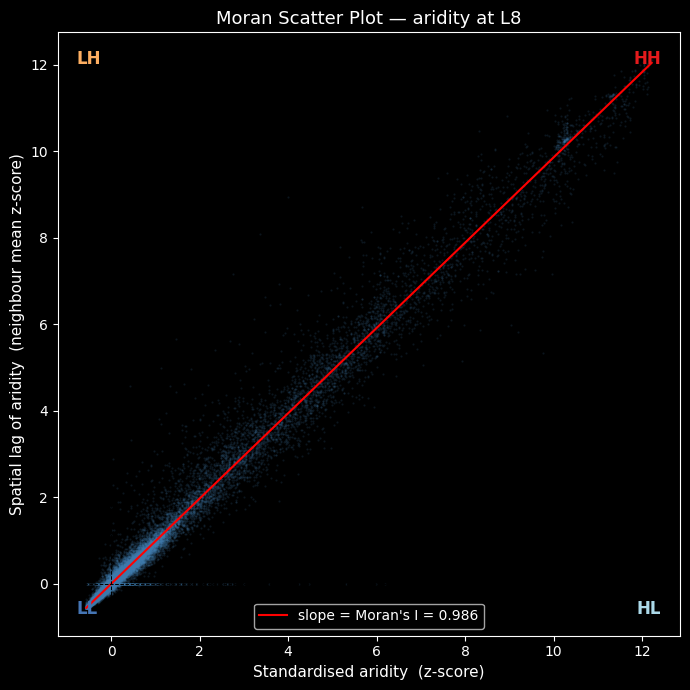

In [7]:
# Cell 12 — Moran scatter plot
y_std = (y - y.mean()) / y.std()
wy    = libpysal.weights.lag_spatial(w, y_std)

fig, ax = plt.subplots(figsize=(7, 7))

# tiny points, very low alpha — 190k points fill quickly
ax.scatter(y_std, wy, s=0.3, alpha=0.15, color='steelblue', rasterized=True)

m, b = np.polyfit(y_std, wy, 1)
x_line = np.linspace(y_std.min(), y_std.max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
        label=f"slope = Moran's I = {m:.3f}")

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvline(0, color='black', linewidth=0.7, linestyle='--')

ax.text(0.97, 0.97, 'HH', transform=ax.transAxes, ha='right', va='top',    fontsize=12, color='#e41a1c', fontweight='bold')
ax.text(0.03, 0.97, 'LH', transform=ax.transAxes, ha='left',  va='top',    fontsize=12, color='#fdae61', fontweight='bold')
ax.text(0.97, 0.03, 'HL', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, color='#abd9e9', fontweight='bold')
ax.text(0.03, 0.03, 'LL', transform=ax.transAxes, ha='left',  va='bottom', fontsize=12, color='#4575b4', fontweight='bold')

ax.set_xlabel('Standardised aridity  (z-score)', fontsize=11)
ax.set_ylabel('Spatial lag of aridity  (neighbour mean z-score)', fontsize=11)
ax.set_title("Moran Scatter Plot — aridity at L8", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
print(f'Regression slope (should equal Moran I): {m:.4f}')
print(f"Moran's I from esda:                     {mi.I:.4f}")

## Step 6 — LISA

**This step takes ~1–2 hours.** LISA permutation cost scales as O(n × permutations): 190k basins × 999 shuffles. Run it and walk away.

If you want to abort and get approximate results faster, reduce `permutations=99` — the classification will be noisier near the p=0.05 boundary but the HH/LL core areas will be the same.

Watch for the `RuntimeWarning: invalid value encountered in divide` from esda — this is benign (islands with zero variance in the permutation distribution get NaN z-scores; their p-values are handled separately).

In [8]:
# Cell 14 — LISA (local Moran's I) — SLOW: ~1–2 hours at 999 permutations
print('Starting LISA — 999 permutations × 190k basins.')
print('Expect ~1–2 hours. Time is printed on completion.')

t0 = time.time()
np.random.seed(42)
lisa = Moran_Local(y, w, permutations=999)
elapsed(t0, 'LISA compute')

SIGNIFICANCE = 0.05
quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

labels = np.where(
    lisa.p_sim < SIGNIFICANCE,
    np.array([quad_map[q] for q in lisa.q]),
    'NS'
)

gdf['lisa_class'] = labels
gdf['lisa_p']     = lisa.p_sim
gdf['lisa_I']     = lisa.Is

counts = pd.Series(labels).value_counts().reindex(['HH', 'LL', 'HL', 'LH', 'NS'], fill_value=0)
print('\nLISA classification counts (p < 0.05):')
for cls, n in counts.items():
    print(f'  {cls}: {n:6,}  ({n / len(gdf) * 100:.1f}%)')
print(f'\n  Total significant: {(labels != "NS").sum():,}  ({(labels != "NS").mean()*100:.1f}%)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## Step 7 — LISA cluster map

At L8 the map will show finer structural detail than L6 — cluster boundaries should be sharper and transition zones more visible. River corridors (HL: humid outliers in arid regions) may resolve more clearly.

Rendering 190k polygons takes a few minutes. Using `linewidth=0` avoids the polygon boundary overprinting that makes dense maps illegible.

In [9]:
# Cell 16 — LISA cluster map
COLOURS = {
    'HH': '#e41a1c',
    'LL': '#4575b4',
    'LH': '#fdae61',
    'HL': '#abd9e9',
    'NS': '#d9d9d9',
}

t0 = time.time()
fig, ax = plt.subplots(figsize=(16, 9))

gdf[gdf['lisa_class'] == 'NS'].plot(ax=ax, color=COLOURS['NS'], linewidth=0)
for cls in ['LL', 'HH', 'HL', 'LH']:
    subset = gdf[gdf['lisa_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=COLOURS[cls], linewidth=0)

legend_entries = {
    'HH — humid cluster core':                COLOURS['HH'],
    'LL — arid cluster core':                 COLOURS['LL'],
    'LH — dry outlier in humid surroundings': COLOURS['LH'],
    'HL — humid outlier in dry surroundings': COLOURS['HL'],
    'NS — not significant':                   COLOURS['NS'],
}
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_entries.items()]
ax.legend(handles=patches, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title(
    f'LISA Cluster Map — Aridity (ari_ix_sav) at L8\n'
    f'Queen contiguity · 999 permutations · p < {SIGNIFICANCE}',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/Users/karlg/Documents/repos/_cedop/spatial/basin08_queen_lisa_ari_python.png',
            dpi=150, bbox_inches='tight')
elapsed(t0, 'Map render + save')
plt.show()
print('Saved → spatial/basin08_queen_lisa_ari_python.png')

Saved → spatial/basin08_queen_lisa_ari_python.png


## Step 8 — Cross-scale comparison: L6 vs L8

The key question: does increasing basin resolution change the spatial autocorrelation structure of aridity? 

Interpretive frame:
- If I **increases** at L8: finer basins are locally more homogeneous — the climate signal dominates at all scales and the queen neighbourhood captures it more tightly
- If I **decreases** at L8: finer resolution resolves within-region variability (topographic effects, rain shadows, coast/interior gradients) that are averaged away at L6
- If I **stays flat**: aridity autocorrelation is scale-invariant across this resolution range — the spatial structure is the same pattern at both granularities

LISA class percentages may shift even if global I is stable — specifically, expect more HL (humid outliers in arid regions) at L8 as river corridors and coastal strips become individually identifiable basins.

In [ ]:
# Cell 18 — cross-scale comparison summary
n_total = len(gdf)
hh_pct  = (gdf['lisa_class'] == 'HH').sum() / n_total * 100
ll_pct  = (gdf['lisa_class'] == 'LL').sum() / n_total * 100
hl_pct  = (gdf['lisa_class'] == 'HL').sum() / n_total * 100
lh_pct  = (gdf['lisa_class'] == 'LH').sum() / n_total * 100
ns_pct  = (gdf['lisa_class'] == 'NS').sum() / n_total * 100

# L6 reference values from Notebook 01
L6 = dict(I=0.9628, I_log=0.9731, HH=4.6, LL=30.0, HL=1.4, LH=0.0, NS=64.0)

print('=== Cross-scale comparison — ari_ix_sav, queen contiguity, 999 perms ===')
print(f'{"":30s}  {"L6":>10}  {"L8":>10}  {"Δ":>8}')
print('-' * 62)
print(f'{"Basins":30s}  {16397:>10,}  {n_total:>10,}')
print(f'{"Global Moran I (raw)":30s}  {L6["I"]:>10.4f}  {mi.I:>10.4f}  {mi.I - L6["I"]:>+8.4f}')
print(f'{"HH %":30s}  {L6["HH"]:>10.1f}  {hh_pct:>10.1f}  {hh_pct - L6["HH"]:>+8.1f}')
print(f'{"LL %":30s}  {L6["LL"]:>10.1f}  {ll_pct:>10.1f}  {ll_pct - L6["LL"]:>+8.1f}')
print(f'{"HL %":30s}  {L6["HL"]:>10.1f}  {hl_pct:>10.1f}  {hl_pct - L6["HL"]:>+8.1f}')
print(f'{"LH %":30s}  {L6["LH"]:>10.1f}  {lh_pct:>10.1f}  {lh_pct - L6["LH"]:>+8.1f}')
print(f'{"NS %":30s}  {L6["NS"]:>10.1f}  {ns_pct:>10.1f}  {ns_pct - L6["NS"]:>+8.1f}')
print()
print('Interpretation: see Step 8 markdown above.')

## Step 9 — Sensitivity check: log transform

Same check as L6. At L8 the right-skewed tail may be more or less pronounced depending on whether finer basins resolve extreme wet outliers more precisely.

In [ ]:
# Cell 20 — sensitivity: log transform
y_log = np.log1p(y)
t0 = time.time()
np.random.seed(42)
mi_log = Moran(y_log, w, permutations=999)
elapsed(t0, 'Log Moran')

print('=== Sensitivity: log(1 + ari_ix_sav) at L8 ===')
print(f"Moran's I (raw):             {mi.I:.4f}   (L6 raw:  0.9628)")
print(f"Moran's I (log-transformed): {mi_log.I:.4f}   (L6 log:  0.9731)")
print(f'Absolute difference:         {abs(mi.I - mi_log.I):.4f}')
print()
if abs(mi.I - mi_log.I) < 0.05:
    print('→ Transform makes little difference — same conclusion as L6.')
else:
    print('→ Transform changes I noticeably at L8 — document which is canonical.')